# TPS Over Time Plot

This notebook loads commit TPS data, node-side client receive-rate CSV samples, and leader PrePrepare process-rate CSV samples, then plots throughput over time and prints summary metrics for analysis.


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "axes.facecolor": "#fcfcfd",
    "figure.facecolor": "white",
    "font.size": 12,
})

In [ ]:
import pandas as pd

df = pd.read_csv("logs/node_3_throughput.csv")
df["time"] = pd.to_datetime(df["time"])
df["gap_ms"] = df["time"].diff().dt.total_seconds() * 1000

max_idx = df["gap_ms"].idxmax()
before = df.loc[max_idx - 1]
after = df.loc[max_idx]

print(df["gap_ms"].describe(percentiles=[0.95, 0.99]))

print("\nMaximum gap:")
print(f"Gap:      {after['gap_ms']:.3f} ms")
print(f"From:     {before['time']}  (seq={before['seq']}, view={before['view']})")
print(f"To:       {after['time']}  (seq={after['seq']}, view={after['view']})")

count      59.000000
mean      941.673769
std        78.741954
min       905.917536
50%       928.565501
95%      1203.235161
99%      1240.183663
max      1258.449810
Name: gap_ms, dtype: float64

Maximum gap:
Gap:      1258.450 ms
From:     2026-09-06 21:54:02.429574140+00:00  (seq=13750, view=7)
To:       2026-09-06 21:54:03.688023950+00:00  (seq=14000, view=9)


,view,time,leader_id,executed_slots,elapsed_seconds,tput_measurement,seq,elapsed_from_first_sec
0,1,2026-09-07 18:23:41.802750493-06:00,1,497,1.828482,271.810188,500,0.000000
1,1,2026-09-07 18:23:42.739212881-06:00,1,747,2.764944,270.168195,750,0.936462
2,1,2026-09-07 18:23:43.642548611-06:00,1,997,3.668280,271.789505,1000,1.839798
3,1,2026-09-07 18:23:44.572140716-06:00,1,1247,4.597872,271.212417,1250,2.769390
4,1,2026-09-07 18:23:45.478929531-06:00,1,1497,5.504661,271.951352,1500,3.676179


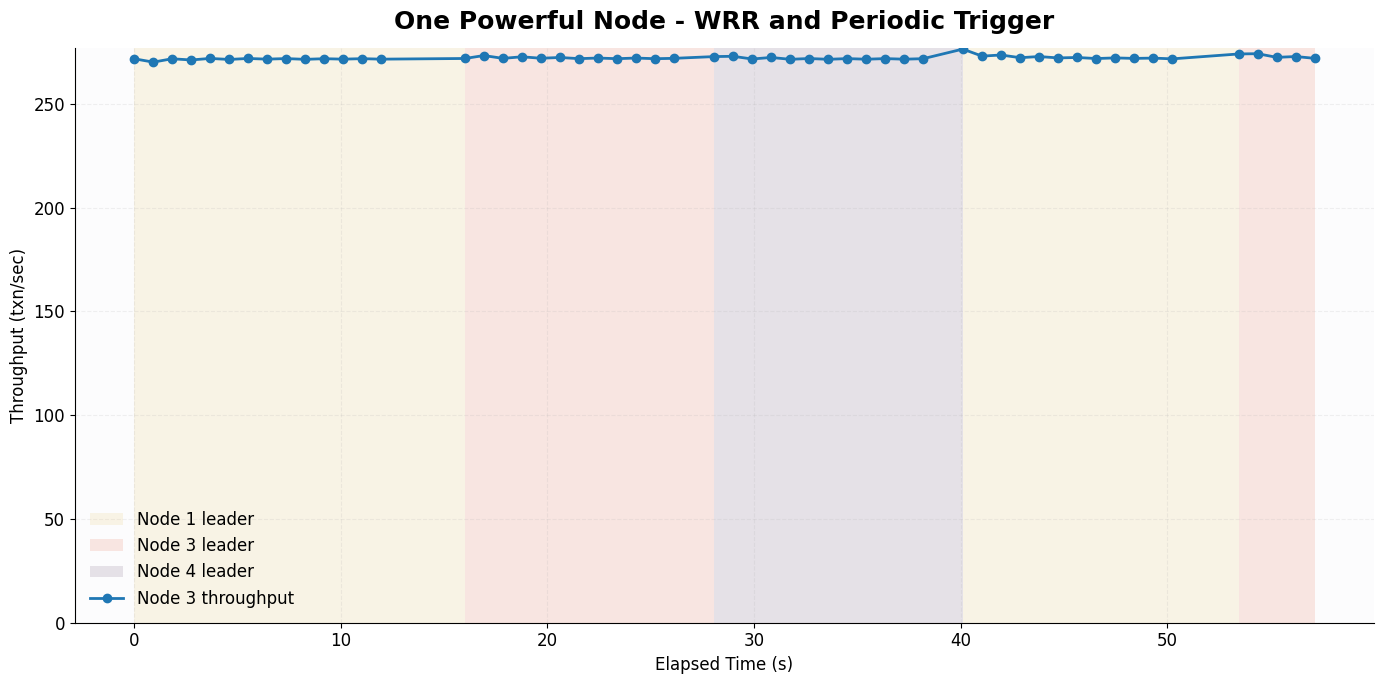

In [5]:
# Change this to pick which node throughput CSV to plot.
node_id = 3

view_start = 0

view_end = 30

throughput_csv_path = Path("logs") / f"node_{node_id}_throughput.csv"
assert throughput_csv_path.exists(), f"Missing file: {throughput_csv_path.resolve()}"

throughput_df = pd.read_csv(throughput_csv_path)
throughput_df["time"] = pd.to_datetime(throughput_df["time"])

throughput_df = throughput_df.sort_values(["time"]).reset_index(drop=True)

# Remove the first 3 seconds of measurements from each view.
throughput_df = throughput_df[throughput_df["elapsed_seconds"] >= 1].copy()
throughput_df = throughput_df.reset_index(drop=True)

# throughput_df = throughput_df[
#     throughput_df["view"].between(view_start, view_end)
# ].copy()
# high_mask = throughput_df["tput_measurement"] > 4500

# high_values = throughput_df.loc[high_mask, "tput_measurement"]

# if len(high_values) > 0:
#     high_min = high_values.min()
#     high_max = high_values.max()

#     if high_min == high_max:
#         throughput_df.loc[high_mask, "tput_measurement"] = 2100
#     else:
#         throughput_df.loc[high_mask, "tput_measurement"] = 4000



throughput_df["elapsed_from_first_sec"] = (
    throughput_df["time"] - throughput_df["time"].iloc[0]
).dt.total_seconds()

# throughput_df.to_csv(f"logs/node_{node_id}_throughput_cleaned.csv", index=False)

display(throughput_df.head())

fig, ax = plt.subplots(figsize=(14, 7))

leader_colors = {
    1: "#E9C46A",
    2: "#2A9D8F",
    3: "#E76F51",
    4: "#6D597A",
}
leader_change = throughput_df["leader_id"].ne(throughput_df["leader_id"].shift())
segment_id = leader_change.cumsum()
leader_segments = (
    throughput_df.groupby(segment_id)
    .agg(
        leader_id=("leader_id", "first"),
        start_sec=("elapsed_from_first_sec", "first"),
    )
    .reset_index(drop=True)
)
leader_segments["end_sec"] = leader_segments["start_sec"].shift(-1)
leader_segments.loc[leader_segments.index[-1], "end_sec"] = throughput_df[
    "elapsed_from_first_sec"
].iloc[-1]

seen_leaders = set()
for segment in leader_segments.itertuples(index=False):
    leader = int(segment.leader_id)
    label = f"Node {leader} leader" if leader not in seen_leaders else None
    ax.axvspan(
        segment.start_sec,
        segment.end_sec,
        color=leader_colors.get(leader, "#8D99AE"),
        alpha=0.16,
        label=label,
        linewidth=0,
    )
    seen_leaders.add(leader)

ax.plot(
    throughput_df["elapsed_from_first_sec"],
    throughput_df["tput_measurement"],
    marker="o",
    linewidth=2,
    label=f"Node {node_id} throughput",
)

ax.set_title(f"One Powerful Node - WRR and Periodic Trigger", fontsize=18, weight="bold", pad=14)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Throughput (txn/sec)")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [10]:
json_path = Path("logs/report.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"

with json_path.open() as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
# df = df[(df["average_tps"] >= 500) & (df["average_tps"] <= 3000)].copy()

df = df.sort_values("elapsed_sec").reset_index(drop=True)
df = df[df["elapsed_sec"].between(0, 108, inclusive="both")].copy()
df["window_tps_smooth"] = df["window_tps"].rolling(window=10, min_periods=10).mean()

change_mask = df["committed_total"].ne(df["committed_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    plot_df = df.loc[:last_change_idx].copy()
else:
    plot_df = df.copy()

summary = {
    "samples": int(len(df)),
    "plot_samples": int(len(plot_df)),
    "final_committed": int(df["committed_total"].max()),
    "peak_window_tps": float(plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(plot_df["average_tps"].iloc[-1]),
    "elapsed_sec": float(plot_df["elapsed_sec"].iloc[-1]),
}

pd.Series(summary)

samples                117.000000
plot_samples           117.000000
final_committed      94380.000000
peak_window_tps       9900.024849
peak_smoothed_tps     8252.206866
final_average_tps     8121.127608
elapsed_sec             11.621539
dtype: float64

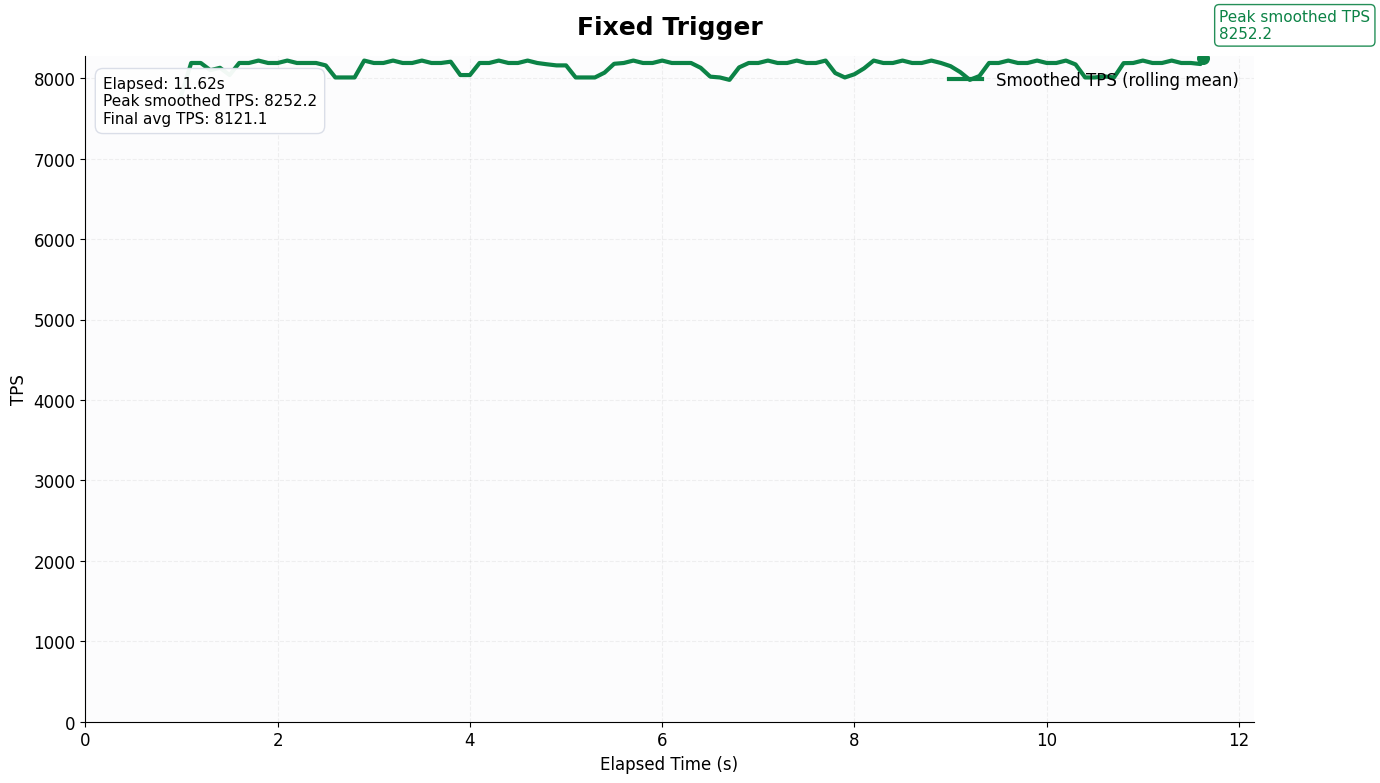

In [11]:
fig, ax1 = plt.subplots()

throughput_color = "#145DA0"
smooth_color = "#0C8346"

# ax1.plot(
#     plot_df["elapsed_sec"],
#     plot_df["window_tps"],
#     color=throughput_color,
#     linewidth=2.0,
#     alpha=0.35,
#     label="Window TPS",
# )
ax1.plot(
    plot_df["elapsed_sec"],
    plot_df["window_tps_smooth"],
    color=smooth_color,
    linewidth=3.0,
    label="Smoothed TPS (rolling mean)",
)

peak_idx = plot_df["window_tps_smooth"].idxmax()
peak_x = plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=smooth_color, alpha=0.9),
)

ax1.set_title("Fixed Trigger", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("TPS")

ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

summary_text = (
    f"Elapsed: {summary['elapsed_sec']:.2f}s\n"
    
    f"Peak smoothed TPS: {summary['peak_smoothed_tps']:.1f}\n"
    f"Final avg TPS: {summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

ax1.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [32]:
output_path = Path("tps_graph_pretty.png")
fig.savefig(output_path, dpi=220, bbox_inches="tight")
output_path.resolve()

PosixPath('/Users/hamzakhawaja/Documents/github/pbftm/tps_graph_pretty.png')

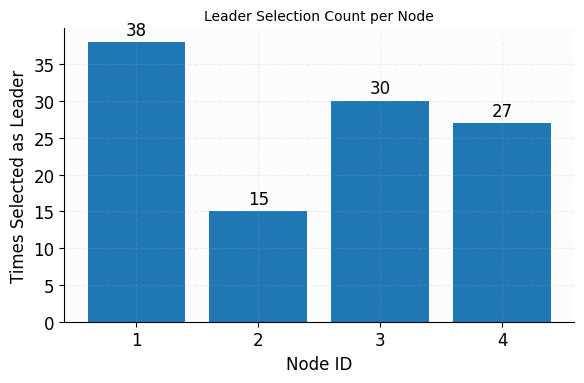

In [71]:
import matplotlib.pyplot as plt

leader_counts = {
    1: 38,
    2: 15,
    3: 30,
    4: 27,
}
# 1,42; 2,6; 3,28; 4,23

nodes = list(leader_counts.keys())
counts = list(leader_counts.values())

plt.figure(figsize=(6, 4))
plt.bar(nodes, counts)

plt.title("Leader Selection Count per Node", fontsize=10)
plt.xlabel("Node ID")
plt.ylabel("Times Selected as Leader")
plt.xticks(nodes)
plt.ylim(bottom=0)

for node, count in zip(nodes, counts):
    plt.text(node, count + 0.5, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Node Client Receive Rate

This section loads the node-side CSV written by `clientReceiveRateLogger` and summarizes receive TPS over time.


In [ ]:
# Change this to pick which node receive-rate CSV to plot.
receive_node_id = 1
receive_rate_csv_path = Path("logs") / f"node_{receive_node_id}_client_receive_rate.csv"
assert receive_rate_csv_path.exists(), f"Missing file: {receive_rate_csv_path.resolve()}"

receive_df = pd.read_csv(receive_rate_csv_path)
receive_df["timestamp"] = pd.to_datetime(receive_df["timestamp"])
receive_df = receive_df.sort_values("elapsed_sec").reset_index(drop=True)

# Trim idle samples after the node stops receiving new client transactions.
change_mask = receive_df["received_total"].ne(receive_df["received_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    receive_plot_df = receive_df.loc[:last_change_idx].copy()
else:
    receive_plot_df = receive_df.copy()

receive_plot_df["window_tps_smooth"] = (
    receive_plot_df["window_tps"].rolling(window=5, min_periods=1).mean()
)

active_receive_df = receive_plot_df[receive_plot_df["received_delta"] > 0].copy()
if active_receive_df.empty:
    active_receive_df = receive_plot_df.copy()

receive_summary = {
    "samples": int(len(receive_df)),
    "plot_samples": int(len(receive_plot_df)),
    "active_samples": int(len(active_receive_df)),
    "final_received": int(receive_plot_df["received_total"].iloc[-1]),
    "elapsed_sec": float(receive_plot_df["elapsed_sec"].iloc[-1]),
    "mean_window_tps_active": float(active_receive_df["window_tps"].mean()),
    "median_window_tps_active": float(active_receive_df["window_tps"].median()),
    "p95_window_tps_active": float(active_receive_df["window_tps"].quantile(0.95)),
    "peak_window_tps": float(receive_plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(receive_plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(receive_plot_df["average_tps"].iloc[-1]),
}

display(pd.Series(receive_summary))
display(receive_plot_df.head())


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

receive_color = "#2563EB"
receive_smooth_color = "#DC2626"
total_color = "#475569"

ax1.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["window_tps"],
    color=receive_color,
    linewidth=1.6,
    alpha=0.30,
    label="Window receive TPS",
)
ax1.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["window_tps_smooth"],
    color=receive_smooth_color,
    linewidth=3.0,
    label="Smoothed receive TPS (5-sample rolling mean)",
)

peak_idx = receive_plot_df["window_tps_smooth"].idxmax()
peak_x = receive_plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = receive_plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=receive_smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed receive TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=receive_smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=receive_smooth_color, alpha=0.9),
)

ax1.set_title(f"Node {receive_node_id} Client Receive Rate Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("Receive TPS")
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["received_total"],
    color=total_color,
    linewidth=2.0,
    alpha=0.65,
    label="Total received",
)
ax2.set_ylabel("Total Received Transactions")
ax2.grid(False)

summary_text = (
    f"Elapsed: {receive_summary['elapsed_sec']:.2f}s\n"
    f"Final received: {receive_summary['final_received']:,}\n"
    f"Mean active TPS: {receive_summary['mean_window_tps_active']:.1f}\n"
    f"Median active TPS: {receive_summary['median_window_tps_active']:.1f}\n"
    f"P95 active TPS: {receive_summary['p95_window_tps_active']:.1f}\n"
    f"Final avg TPS: {receive_summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
receive_output_path = Path(f"node_{receive_node_id}_client_receive_rate.png")
fig.savefig(receive_output_path, dpi=220, bbox_inches="tight")
receive_output_path.resolve()


## Leader PrePrepare Process Rate

This section loads the leader-side CSV written by `leaderPreprepareRateLogger` and summarizes locally processed PrePrepares over time.


In [ ]:
# Change this to pick which leader PrePrepare process-rate CSV to plot.
preprepare_node_id = 1
preprepare_rate_csv_path = Path("logs") / f"node_{preprepare_node_id}_leader_preprepare_rate.csv"
assert preprepare_rate_csv_path.exists(), f"Missing file: {preprepare_rate_csv_path.resolve()}"

preprepare_df = pd.read_csv(preprepare_rate_csv_path)
preprepare_df["timestamp"] = pd.to_datetime(preprepare_df["timestamp"])
preprepare_df = preprepare_df.sort_values("elapsed_sec").reset_index(drop=True)

# Trim idle samples after the leader stops processing new PrePrepares.
change_mask = preprepare_df["preprepare_total"].ne(preprepare_df["preprepare_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    preprepare_plot_df = preprepare_df.loc[:last_change_idx].copy()
else:
    preprepare_plot_df = preprepare_df.copy()

preprepare_plot_df["window_preprepare_per_sec_smooth"] = (
    preprepare_plot_df["window_preprepare_per_sec"].rolling(window=5, min_periods=1).mean()
)

active_preprepare_df = preprepare_plot_df[preprepare_plot_df["preprepare_delta"] > 0].copy()
if active_preprepare_df.empty:
    active_preprepare_df = preprepare_plot_df.copy()

preprepare_summary = {
    "samples": int(len(preprepare_df)),
    "plot_samples": int(len(preprepare_plot_df)),
    "active_samples": int(len(active_preprepare_df)),
    "final_preprepares": int(preprepare_plot_df["preprepare_total"].iloc[-1]),
    "elapsed_sec": float(preprepare_plot_df["elapsed_sec"].iloc[-1]),
    "mean_window_preprepare_per_sec_active": float(active_preprepare_df["window_preprepare_per_sec"].mean()),
    "median_window_preprepare_per_sec_active": float(active_preprepare_df["window_preprepare_per_sec"].median()),
    "p95_window_preprepare_per_sec_active": float(active_preprepare_df["window_preprepare_per_sec"].quantile(0.95)),
    "peak_window_preprepare_per_sec": float(preprepare_plot_df["window_preprepare_per_sec"].max()),
    "peak_smoothed_preprepare_per_sec": float(preprepare_plot_df["window_preprepare_per_sec_smooth"].max()),
    "final_average_preprepare_per_sec": float(preprepare_plot_df["average_preprepare_per_sec"].iloc[-1]),
}

display(pd.Series(preprepare_summary))
display(preprepare_plot_df.head())


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

preprepare_color = "#0F766E"
preprepare_smooth_color = "#EA580C"
total_color = "#475569"

ax1.plot(
    preprepare_plot_df["elapsed_sec"],
    preprepare_plot_df["window_preprepare_per_sec"],
    color=preprepare_color,
    linewidth=1.6,
    alpha=0.30,
    label="Window PrePrepare/sec",
)
ax1.plot(
    preprepare_plot_df["elapsed_sec"],
    preprepare_plot_df["window_preprepare_per_sec_smooth"],
    color=preprepare_smooth_color,
    linewidth=3.0,
    label="Smoothed PrePrepare/sec (5-sample rolling mean)",
)

peak_idx = preprepare_plot_df["window_preprepare_per_sec_smooth"].idxmax()
peak_x = preprepare_plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = preprepare_plot_df.loc[peak_idx, "window_preprepare_per_sec_smooth"]
ax1.scatter([peak_x], [peak_y], color=preprepare_smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed PrePrepare/sec\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=preprepare_smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=preprepare_smooth_color, alpha=0.9),
)

ax1.set_title(f"Node {preprepare_node_id} Leader PrePrepare Process Rate Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("PrePrepare/sec")
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(
    preprepare_plot_df["elapsed_sec"],
    preprepare_plot_df["preprepare_total"],
    color=total_color,
    linewidth=2.0,
    alpha=0.65,
    label="Total PrePrepares",
)
ax2.set_ylabel("Total Leader PrePrepares Processed")
ax2.grid(False)

summary_text = (
    f"Elapsed: {preprepare_summary['elapsed_sec']:.2f}s\n"
    f"Final PrePrepares: {preprepare_summary['final_preprepares']:,}\n"
    f"Mean active: {preprepare_summary['mean_window_preprepare_per_sec_active']:.1f}/s\n"
    f"Median active: {preprepare_summary['median_window_preprepare_per_sec_active']:.1f}/s\n"
    f"P95 active: {preprepare_summary['p95_window_preprepare_per_sec_active']:.1f}/s\n"
    f"Final avg: {preprepare_summary['final_average_preprepare_per_sec']:.1f}/s"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
preprepare_output_path = Path(f"node_{preprepare_node_id}_leader_preprepare_rate.png")
fig.savefig(preprepare_output_path, dpi=220, bbox_inches="tight")
preprepare_output_path.resolve()


## Cumulative Committed Requests Over Time

This section plots the total number of committed client requests against elapsed experiment time using the complete `logs/ch.json` series.


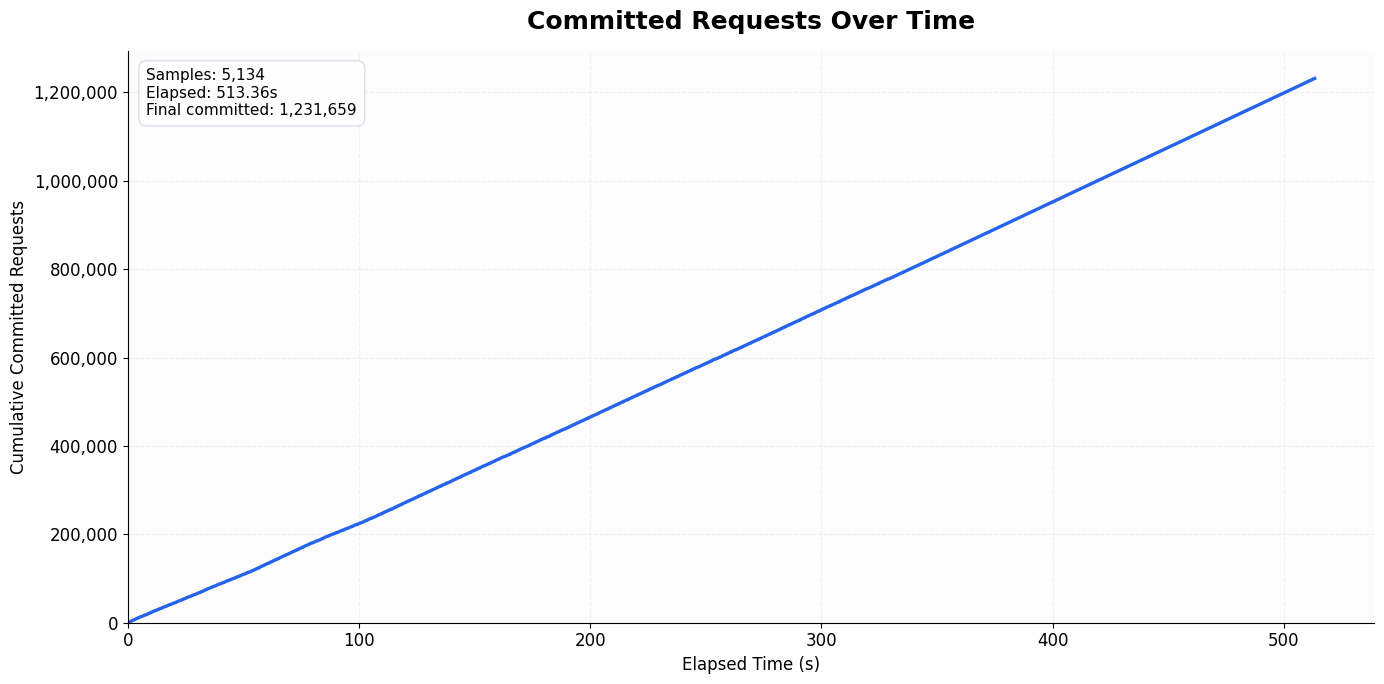

In [32]:
committed_json_path = Path("logs/ch.json")
assert committed_json_path.exists(), f"Missing file: {committed_json_path.resolve()}"

with committed_json_path.open() as f:
    committed_raw = json.load(f)

committed_df = pd.DataFrame(committed_raw)
required_columns = {"elapsed_sec", "committed_total"}
missing_columns = required_columns - set(committed_df.columns)
assert not missing_columns, f"Missing columns: {sorted(missing_columns)}"

committed_df = (
    committed_df[["elapsed_sec", "committed_total"]]
    .dropna()
    .sort_values("elapsed_sec")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    committed_df["elapsed_sec"],
    committed_df["committed_total"],
    color="#2563EB",
    linewidth=2.4,
)
ax.set_title("Committed Requests Over Time", fontsize=18, weight="bold", pad=16)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

final_elapsed = committed_df["elapsed_sec"].iloc[-1]
final_committed = int(committed_df["committed_total"].iloc[-1])
ax.text(
    0.015,
    0.97,
    f"Samples: {len(committed_df):,}\n"
    f"Elapsed: {final_elapsed:.2f}s\n"
    f"Final committed: {final_committed:,}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

plt.tight_layout()
plt.show()


## Fixed vs Adaptive: Cumulative Commits Through 800 Seconds

This comparison uses experiment-relative elapsed time and the same 800-second observation window. `logs/ch.json` is the fixed-only run, while `fullrun_adaptive_100mssampling/ch.json` is the adaptive run. Both files use approximately 100 ms sampling.


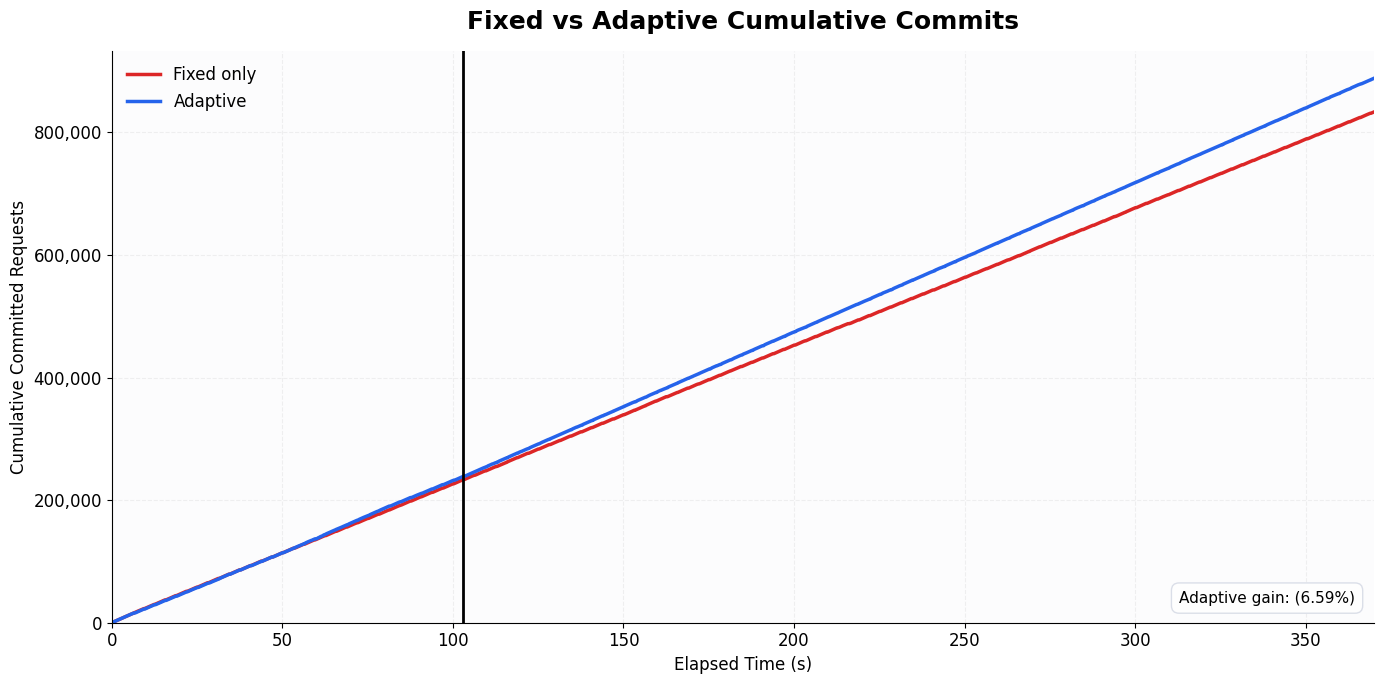

fixed_committed_by_800s       833054.00000
adaptive_committed_by_800s    887986.00000
adaptive_commit_gain           54932.00000
adaptive_gain_percent              6.59405
dtype: float64

In [7]:
comparison_cutoff_sec = 370
comparison_paths = {
    "Fixed only": Path("fixed_full/ch.json"),
    "Adaptive": Path("adaptive/ch.json"),
}
comparison_colors = {
    "Fixed only": "#DC2626",
    "Adaptive": "#2563EB",
}

comparison_frames = {}
for label, path in comparison_paths.items():
    assert path.exists(), f"Missing file: {path.resolve()}"
    with path.open() as f:
        records = json.load(f)

    frame = pd.DataFrame(records)
    required_columns = {"elapsed_sec", "committed_total"}
    missing_columns = required_columns - set(frame.columns)
    assert not missing_columns, f"{path} is missing columns: {sorted(missing_columns)}"

    frame = (
        frame[["elapsed_sec", "committed_total"]]
        .dropna()
        .sort_values("elapsed_sec")
        .drop_duplicates("elapsed_sec", keep="last")
    )
    frame = frame[frame["elapsed_sec"] <= comparison_cutoff_sec].copy()
    assert not frame.empty, f"{path} has no samples through {comparison_cutoff_sec}s"
    comparison_frames[label] = frame

fig, ax = plt.subplots(figsize=(14, 7))
for label, frame in comparison_frames.items():
    ax.plot(
        frame["elapsed_sec"],
        frame["committed_total"],
        color=comparison_colors[label],
        linewidth=2.5,
        label=label,
    )

fixed_committed_800 = int(comparison_frames["Fixed only"]["committed_total"].iloc[-1])
adaptive_committed_800 = int(comparison_frames["Adaptive"]["committed_total"].iloc[-1])
commit_gain = adaptive_committed_800 - fixed_committed_800
commit_gain_pct = 100.0 * commit_gain / fixed_committed_800

ax.set_title("Fixed vs Adaptive Cumulative Commits", fontsize=18, weight="bold", pad=16)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests")
ax.set_xlim(0, comparison_cutoff_sec)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend(loc="upper left", frameon=False)
ax.text(
    0.985,
    0.03,
    # f"At ~800s\n"
    # f"Fixed: {fixed_committed_800:,}\n"
    # f"Adaptive: {adaptive_committed_800:,}\n"
    f"Adaptive gain: ({commit_gain_pct:.2f}%)",
    transform=ax.transAxes,
    va="bottom",
    ha="right",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)
ax.axvline(
    x=103,
    color="black",
    linewidth=2,
    linestyle="-",
    label="108s",
)
plt.tight_layout()
plt.show()

pd.Series({
    "fixed_committed_by_800s": fixed_committed_800,
    "adaptive_committed_by_800s": adaptive_committed_800,
    "adaptive_commit_gain": commit_gain,
    "adaptive_gain_percent": commit_gain_pct,
})


In [90]:
tput = 180
num = 0
while tput < 200:
    tput = tput*1.01
    num += 1
print(num)


11
